# Forecasting Typhoid Fever Cases in Taiwan using Temporal Features and PBT-Tuned XGBoost

# I. Introduction

Typhoid fever, a systemic infection caused by _Salmonella enterica_ serotype Typhi, is primarily transmitted via the fecal-oral route through the consumption of contaminated food or water. While global incidence has decreased, the disease remains a public health concern, particularly in regions with inadequate sanitation infrastructure. In Taiwan, typhoid fever occurs at low levels, with cases presenting as both imported, frequently from Southeast Asia, and sporadic indigenous infections, indicating ongoing local transmission. Control efforts in Taiwan focus on stringent food safety regulations and public health education to mitigate the risk of both imported and locally acquired cases. 

To further understand disease dynamics, the last 12 months of typhoid fever cases in Taiwan will be predicted using an XGBoost model, with hyperparameters optimized via Population Based Training (PBT) and evaluated with a rolling origin cross-validation strategy (implemented using `scikit-learn`'s `TimeSeriesSplit`). The model will utilize lagged case data as input features.

# II. Dataset
The dataset for this project covers typhoid fever cases nationwide [[1]](https://nidss.cdc.gov.tw/en/nndss/disease?id=002) in Taiwan, spanning from January 1993 to April 2025 (with the latest date being April 12, 2025). It includes both imported and indigenous cases, providing a comprehensive view of the disease's epidemiology in the region. The data is organized by date of onset for each case.

In this project, I limited the dataset to only cover cases until December 2011.

In [5]:
import pandas as pd

# Load the dataset
filename= 'DATA/typhoid-fever-nationwide-tw-monthly.csv'
df = pd.read_csv(filename)
df['DATE'] = pd.to_datetime(df['Onset Year-Month'].astype(str) + '01', format='%Y%m%d')
df = df[df['DATE'] <= '2011-12-31'] # until Dec 2011 only
df.columns

Index(['Onset Year-Month', 'Number of Confirmed Cases', 'DATE'], dtype='object')

# III. Exploratory data analysis and feature engineering

<Figure size 640x480 with 0 Axes>

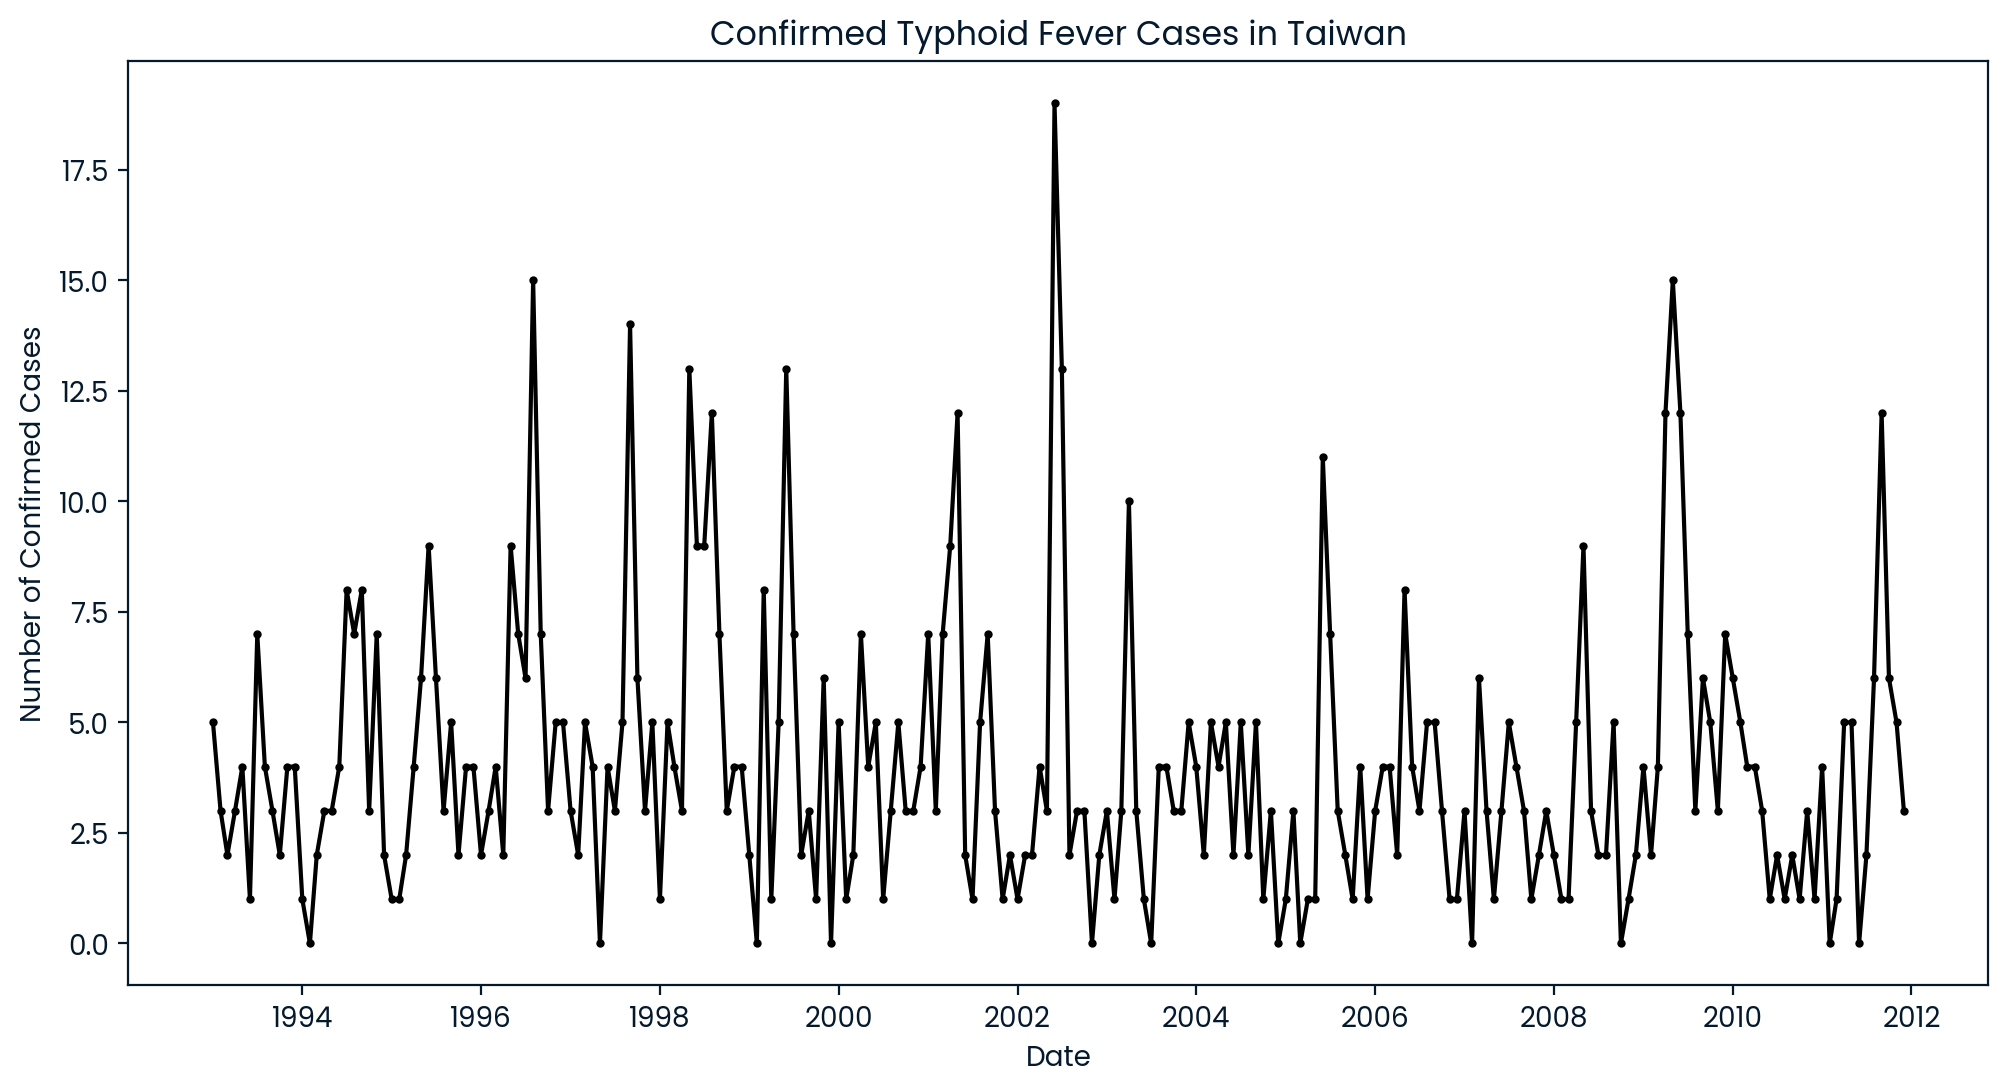

In [6]:
import matplotlib.pyplot as plt

# Plot the Number of Confirmed Cases vs DATE as a bar graph
plt.clf()
plt.figure(figsize=(12, 6))
plt.plot(df['DATE'], df['Number of Confirmed Cases'], marker='o', color='black', label='Data', ms=2)
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.title('Confirmed Typhoid Fever Cases in Taiwan')
plt.grid(False)
plt.show()

The time series plot highlights peaks in cases before 2012, wherein the highest number of cases was recorded in June 2002.

To guide the feature engineering process, Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) analyses were initially performed on the historical typhoid fever case time series. The examination of statistically significant lags identified through the decay and spikes in the ACF and PACF plots provided an empirical basis for determining the relevant temporal dependencies. This analysis informed the subsequent feature engineering step, where lagged features of the typhoid fever case counts, ranging from 1 to 12 months, were explicitly created as input variables for the machine learning model. By grounding the selection of these autoregressive features in the time series' autocorrelation structure, the model was better equipped to capture the inherent temporal dynamics crucial for accurate forecasting.

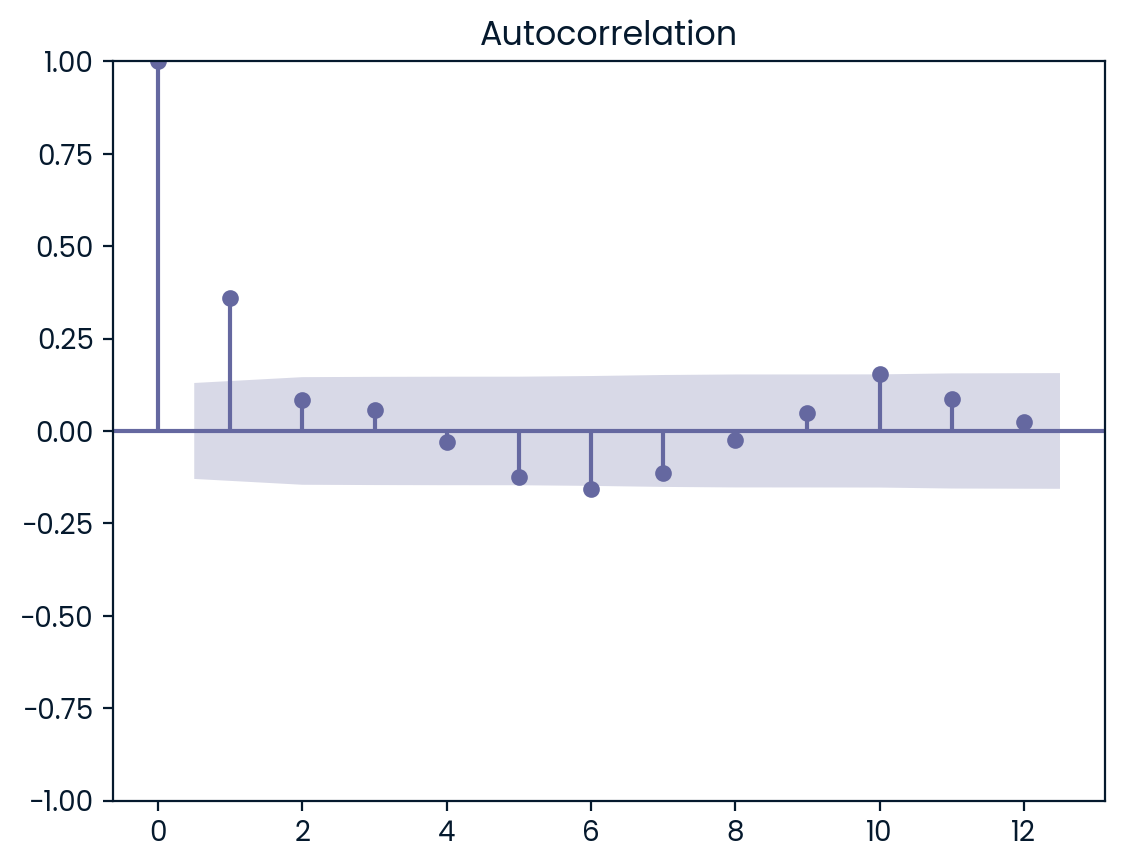

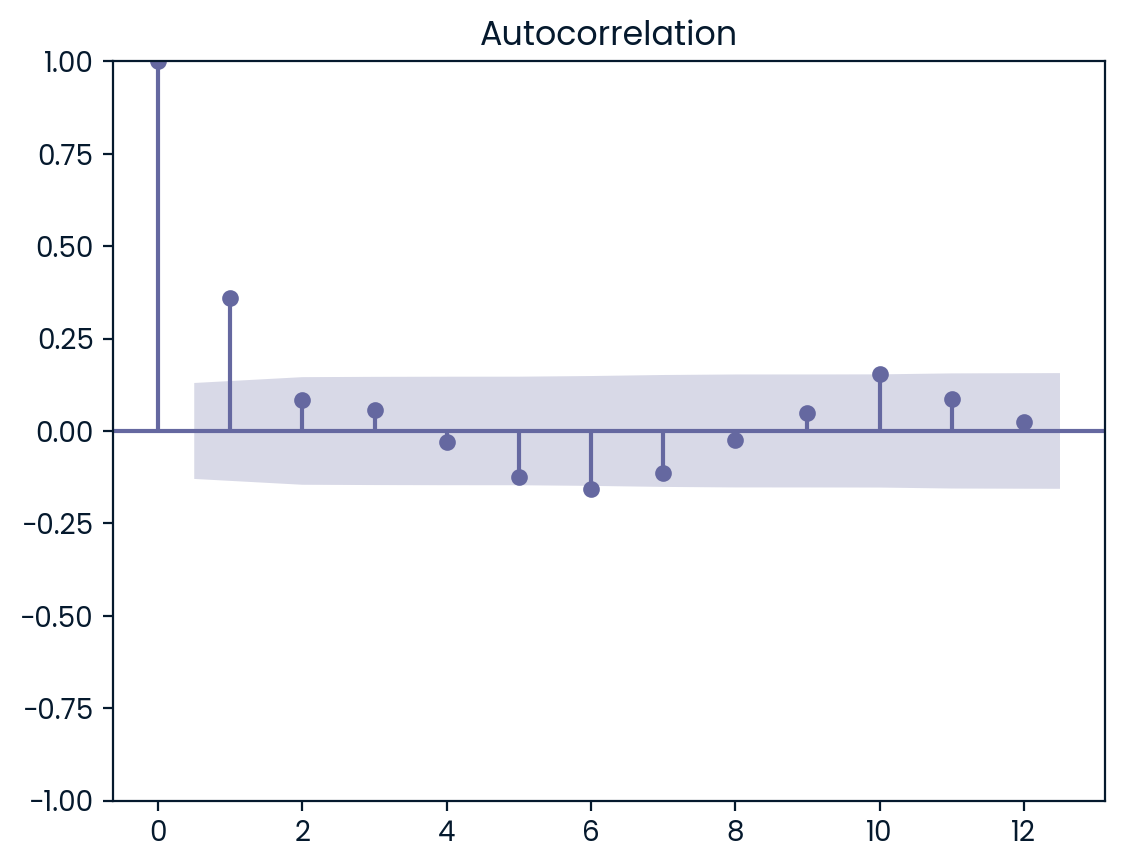

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_ccf
nlags=12
plot_acf(df['Number of Confirmed Cases'], lags=nlags)

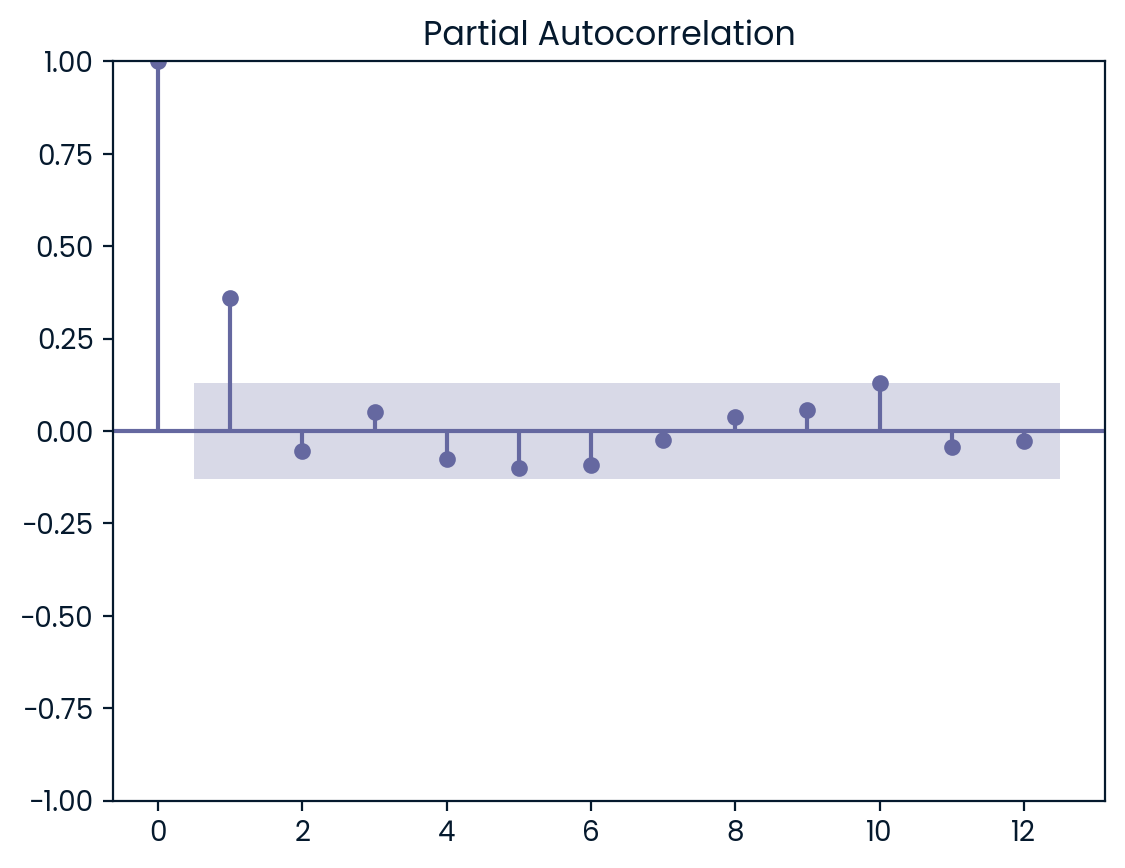

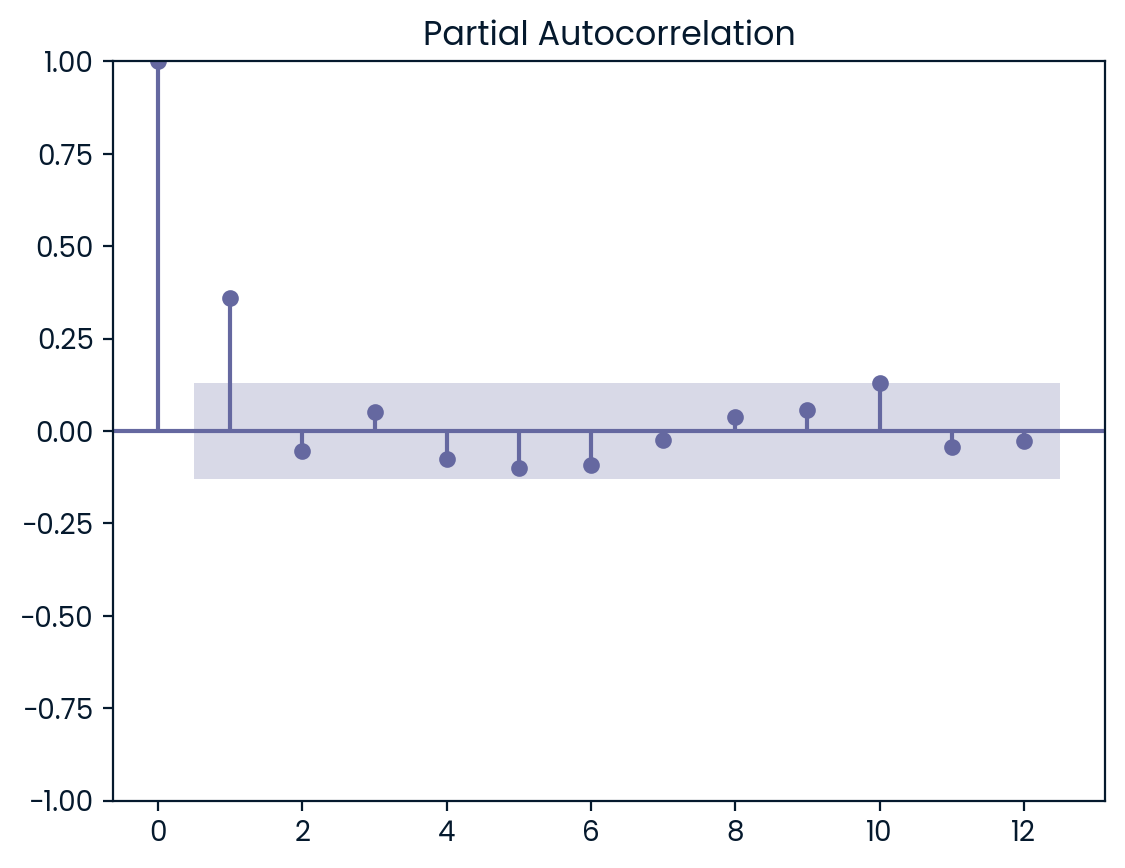

In [5]:
from statsmodels.graphics.tsaplots import plot_pacf
nlags=12
plot_pacf(df['Number of Confirmed Cases'], lags=nlags)

Based on ACF and PACF plots, I decided to use the number of cases from 1, 6, and 10 months prior as key features for our model. This helped the model understand how past case numbers influence future counts.

## Ray Tune-based population-based training with TimeSeriesSplit
To predict the last 12 months of typhoid fever cases, a Population Based Training (PBT) approach, implemented via the ray.tune library, was employed in conjunction with a TimeSeriesSplit cross-validation strategy. Lag-based features, capturing historical data from 1 to 12 months prior, were engineered to enable the model to learn temporal dependencies. To accommodate this feature engineering, the initial 12 months were reserved. The PBT method involved training a population of XGBoost models in parallel across 12 sequential folds generated by TimeSeriesSplit. Within each fold, PBT concurrently searched for and adapted hyperparameters that minimized prediction error across the population. This allowed for the parallel exploration (random perturbation) and exploitation (copying successful hyperparameters from better-performing agents) of promising configurations based on validation performance within each TimeSeriesSplit fold. The final "best" model was selected based on the agent within the PBT population that achieved the lowest Mean Absolute Error (MAE) on the validation set of the fold that ultimately yielded the best performance on its corresponding test set. The MAE of this selected best model was recorded for comparison. 


### On XGBoost
XGBoost was chosen for its effectiveness with time series data, its ability to model non-linear relationships, handle missing data, and prevent overfitting, making it a robust choice for capturing complex temporal patterns without extensive preprocessing.

### On TimeSeriesSplit
TimeSeriesSplit is a cross-validation technique specifically designed for time series data, often referred to as time-aware validation. Unlike traditional cross-validation methods that randomly shuffle data, TimeSeriesSplit respects the inherent temporal order of the data. It works by creating a series of train-test splits where the training sets always precede the test sets in time. For each split, the model is trained on historical data and then evaluated on future, unseen data points. This forward-chaining approach ensures that the model evaluation mimics real-world forecasting scenarios, preventing the leakage of future information into the training process and providing a more realistic assessment of the model's predictive capabilities over time.

In [2]:
!pip install ray

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 104.6 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python3 -m pip install --upgrade pip


2025-04-30 01:57:09,335	WARNING services.py:2159 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.98gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-04-30 01:57:09,514	INFO worker.py:1888 -- Started a local Ray instance.
2025-04-30 01:57:10,418	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2025-04-30 01:57:10,421	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
2025-04-30 01:57:10

2025-04-30 01:57:16,889	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/repl/ray_results/pbt_xgboost_tuning_fold_1' in 0.0141s.
2025-04-30 01:57:16,973	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
2025-04-30 01:57:16,980	WARNING callback.py:136 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


Fold 1 MAE: 1.6667, RMSE: 2.6458, R²: -1.4057


2025-04-30 01:57:22,930	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/repl/ray_results/pbt_xgboost_tuning_fold_2' in 0.0151s.
2025-04-30 01:57:23,008	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
2025-04-30 01:57:23,015	WARNING callback.py:136 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


Fold 2 MAE: 2.8333, RMSE: 3.3665, R²: -0.0080


...

2025-04-30 01:58:20,964	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/repl/ray_results/pbt_xgboost_tuning_fold_11' in 0.0141s.
2025-04-30 01:58:21,011	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
2025-04-30 01:58:21,018	WARNING callback.py:136 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


Fold 11 MAE: 2.0833, RMSE: 2.2546, R²: -0.8915


2025-04-30 01:58:26,973	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/repl/ray_results/pbt_xgboost_tuning_fold_12' in 0.0146s.


Fold 12 MAE: 2.3333, RMSE: 3.2914, R²: -0.0751

--------------------------------------------------
The index of the best fold (lowest MAE) is: 6
The best MAE achieved is: 1.4167

Hyperparameters of the best fold:
  n_estimators: 134
  learning_rate: 0.0190
  max_depth: 3
  subsample: 0.6886
  colsample_bytree: 0.5414
  reg_lambda: 0.0003
--------------------------------------------------

Best XGBoost model constructed with hyperparameters from the best fold:
Model Parameters (before training on full data): {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.5413650225344846, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.018959706719841842, 'max_bin': None, 'max_cat_threshold': None, 'max_ca

<Figure size 640x480 with 0 Axes>

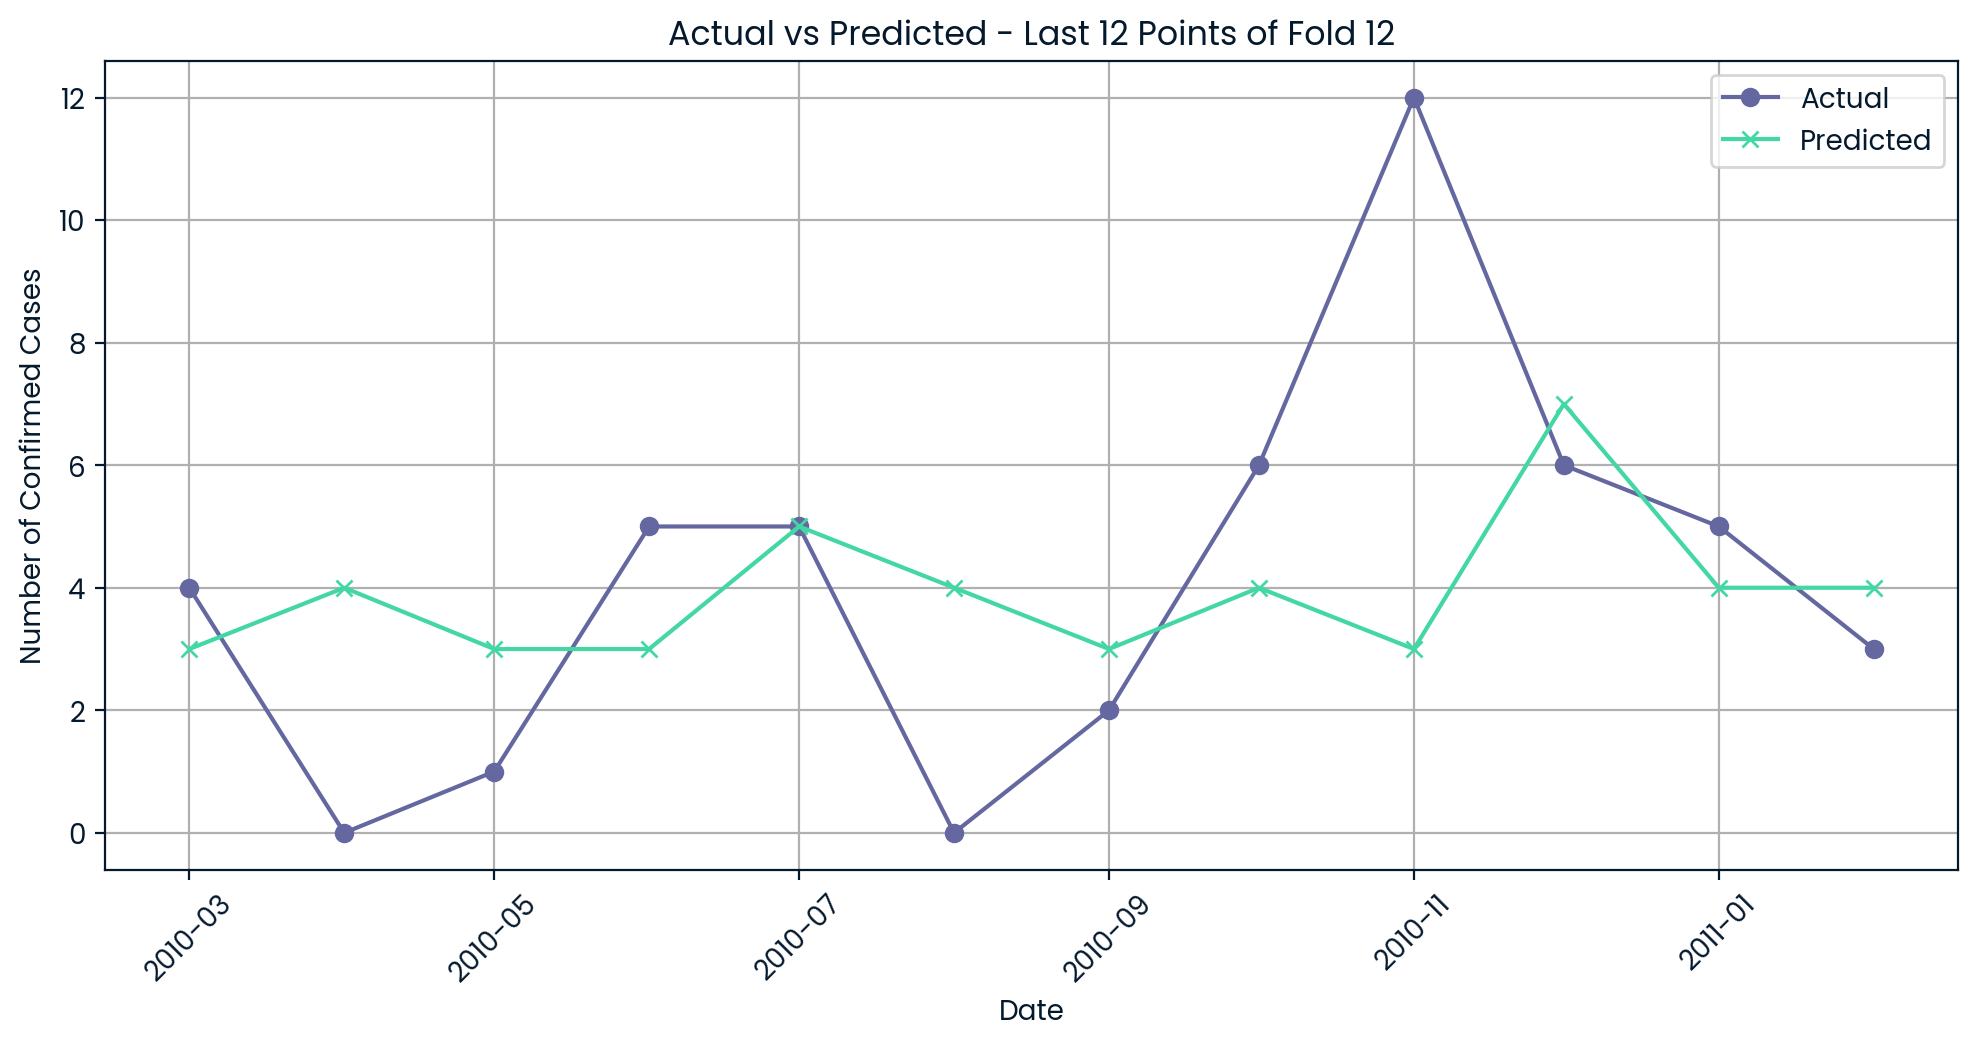

In [7]:
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import os
from ray import tune
from ray.tune.schedulers import PopulationBasedTraining
from ray.tune.search.basic_variant import BasicVariantGenerator


# Feature Selection and Lag Feature Creation
selected_columns = [
    'Number of Confirmed Cases',
    'DATE']
df = df[selected_columns]
columns_to_lag = ['Number of Confirmed Cases']
def create_lag_features(df, columns_to_lag, max_lag=12):
    for lag in range(1, max_lag + 1):
        for col in columns_to_lag:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df.dropna()
def add_recent_zero_count(df, target_column, months=6):
    zero_lag_cols = [f'{target_column}_lag_{i}' for i in range(1, months + 1)]
    df['recent_zero_count'] = df[zero_lag_cols].apply(lambda row: (row == 0).sum(), axis=1)
    return df
df_lagged = create_lag_features(df.copy(), columns_to_lag=columns_to_lag, max_lag=10)
df_lagged = add_recent_zero_count(df_lagged, target_column='Number of Confirmed Cases', months=10)
feature_cols = [col for col in df_lagged.columns if 'lag_1' in col or 'lag_6' in col or 'lag_10' in col] + ['recent_zero_count']
target_col = 'Number of Confirmed Cases'
X = df_lagged[feature_cols].values
y = df_lagged[target_col].values

# TimeSeriesSplit Setup
n_splits = 12
test_size = 12
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

# Ray Tune objective function
def train_xgboost(config, X_train, y_train, X_val, y_val):
    try:
        model = XGBRegressor(
            n_estimators=int(config['n_estimators']),
            learning_rate=config['learning_rate'],
            max_depth=int(config['max_depth']),
            subsample=config['subsample'],
            colsample_bytree=config['colsample_bytree'],
            reg_lambda=config['reg_lambda'],
            random_state=42,
        )
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        return {"rmse": rmse}
    except Exception as e:
        print(f"An error occurred in train_xgboost: {e}")
        return {"rmse": float('inf')}

# Define the hyperparameter search space for Ray Tune
param_space = {
    'n_estimators': tune.quniform(50, 300, 1),
    'learning_rate': tune.loguniform(0.01, 0.3),
    'max_depth': tune.quniform(2, 10, 1),
    'subsample': tune.uniform(0.5, 1.0),
    'colsample_bytree': tune.uniform(0.5, 1.0),
    'reg_lambda': tune.loguniform(1e-6, 10),
}

all_mae_scores = []
all_rmse_scores = []
all_r2_scores = []
all_best_models = []
final_predictions = pd.DataFrame({'DATE': [],
                                    'Actual': [],
                                    'Predicted': [],
                                    'Fold': []})

# Loop through the TimeSeriesSplit folds
for fold_idx, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Split the training fold into training and validation sets for Ray Tune
    X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
        X_train_fold, y_train_fold, test_size=0.2, shuffle=False
    )

    # Set up Ray Tune analysis for PBT
    pbt_scheduler = PopulationBasedTraining(
        time_attr="training_iteration",
        metric="rmse",
        mode="min",
        perturbation_interval=25,
        hyperparam_mutations={
            "n_estimators": tune.randint(50, 300),
            "learning_rate": tune.loguniform(0.01, 0.3),
            "max_depth": tune.randint(2, 10),
            "subsample": tune.uniform(0.5, 1.0),
            "colsample_bytree": tune.uniform(0.5, 1.0),
            "reg_lambda": tune.loguniform(1e-6, 10),
        })

    tune_analysis = tune.Tuner(
            tune.with_parameters(
                train_xgboost,
                X_train=X_train_tune,
                y_train=y_train_tune,
                X_val=X_val_tune,
                y_val=y_val_tune
            ),
            tune_config=tune.TuneConfig(
                num_samples=10,
                search_alg=BasicVariantGenerator(),
                scheduler=pbt_scheduler
            ),
            run_config=tune.RunConfig(
                name=f"pbt_xgboost_tuning_fold_{fold_idx + 1}",
                verbose=0
            ),
            param_space=param_space
        ).fit()

    # Get the best hyperparameters from the PBT run for this fold
    best_result = tune_analysis.get_best_result("rmse", "min", filter_nan_and_inf=False)
    best_config = best_result.config
    all_best_models.append(best_config)

    # Train the final XGBoost model with the best hyperparameters on the fold's full training data
    best_model_fold = XGBRegressor(
        n_estimators=int(best_config['n_estimators']),
        learning_rate=best_config['learning_rate'],
        max_depth=int(best_config['max_depth']),
        subsample=best_config['subsample'],
        colsample_bytree=best_config['colsample_bytree'],
        reg_lambda=best_config['reg_lambda'],
        random_state=42,
    )
    best_model_fold.fit(X_train_fold, y_train_fold)

    # Predict on the test set
    y_pred_fold = best_model_fold.predict(X_test_fold)
    y_pred_rounded_fold = np.round(y_pred_fold)

    # Evaluate the model
    mae_fold = mean_absolute_error(y_test_fold, y_pred_rounded_fold)
    rmse_fold = np.sqrt(mean_squared_error(y_test_fold, y_pred_rounded_fold))
    r2_fold = r2_score(y_test_fold, y_pred_rounded_fold)

    all_mae_scores.append(mae_fold)
    all_rmse_scores.append(rmse_fold)
    all_r2_scores.append(r2_fold)

    # Store the predictions of the current fold
    fold_predictions = pd.DataFrame({
        'DATE': df.iloc[test_index]['DATE'].values,
        'Actual': y_test_fold,
        'Predicted': y_pred_rounded_fold,
        'Fold': fold_idx + 1
    })
    final_predictions = pd.concat([final_predictions, fold_predictions], ignore_index=True)

    print(f"Fold {fold_idx + 1} MAE: {mae_fold:.4f}, RMSE: {rmse_fold:.4f}, R²: {r2_fold:.4f}")

# Find the index of the best fold (lowest MAE)
best_fold_index = np.argmin(all_mae_scores)
best_mae = all_mae_scores[best_fold_index]
best_hyperparameters_best_fold = all_best_models[best_fold_index]

print(f"\n--------------------------------------------------")
print(f"The index of the best fold (lowest MAE) is: {best_fold_index}")
print(f"The best MAE achieved is: {best_mae:.4f}")
print("\nHyperparameters of the best fold:")
print(f"  n_estimators: {int(best_hyperparameters_best_fold['n_estimators'])}")
print(f"  learning_rate: {best_hyperparameters_best_fold['learning_rate']:.4f}")
print(f"  max_depth: {int(best_hyperparameters_best_fold['max_depth'])}")
print(f"  subsample: {best_hyperparameters_best_fold['subsample']:.4f}")
print(f"  colsample_bytree: {best_hyperparameters_best_fold['colsample_bytree']:.4f}")
print(f"  reg_lambda: {best_hyperparameters_best_fold['reg_lambda']:.4f}")
print(f"--------------------------------------------------")

# Construct the best_model with hyperparameters from the best fold
best_model = XGBRegressor(
    n_estimators=int(best_hyperparameters_best_fold['n_estimators']),
    learning_rate=best_hyperparameters_best_fold['learning_rate'],
    max_depth=int(best_hyperparameters_best_fold['max_depth']),
    subsample=best_hyperparameters_best_fold['subsample'],
    colsample_bytree=best_hyperparameters_best_fold['colsample_bytree'],
    reg_lambda=best_hyperparameters_best_fold['reg_lambda'],
    random_state=42  # for reproducibility
)

print("\nBest XGBoost model constructed with hyperparameters from the best fold:")
print(f"Model Parameters (before training on full data): {best_model.get_params()}")

# Train the best model on the entire training dataset
best_model.fit(X, y)

print("\nBest XGBoost model trained on the entire training dataset.")
print(f"Model Parameters (after training on full data): {best_model.get_params()}")

# Get the predictions from the last fold
last_fold_predictions = final_predictions[final_predictions['Fold'] == n_splits]

# Print the actual vs predicted for the last 12 periods
print("\nFinal Predictions (Last 12 periods):")
print(last_fold_predictions.tail(12)[['DATE', 'Actual', 'Predicted']].to_string(index=False))

# Plotting the last 12 points from the last fold
plt.clf()
plt.figure(figsize=(10, 5))
plt.plot(last_fold_predictions.tail(12)['DATE'], last_fold_predictions.tail(12)['Actual'], label='Actual', marker='o')
plt.plot(last_fold_predictions.tail(12)['DATE'], last_fold_predictions.tail(12)['Predicted'], label='Predicted', marker='x')
plt.title(f"Actual vs Predicted - Last 12 Points of Fold {n_splits}")
plt.xlabel("Date")
plt.ylabel("Number of Confirmed Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


During the PBT process across the 12 TimeSeriesSplit folds, the best performing model was identified at the sixth fold. This model, which evolved its hyperparameters through the PBT exploration and exploitation mechanisms within that specific time window, achieved the lowest MAE of 1.417 (in my current run; this may change!) on the fold's validation set, which highlights the most accurate predictions on its corresponding test set.

On a side note, $R^{2}$ score is equal to 1 - $\frac{SS_{res}}{SS_{tot}}$ where $SS_{res}$ and $SS_{tot}$ are the sum of squared residuals and total sum of squares, respectively. Hence, it is **possible** to have $R^{2}$ values < -1. Nevertheless, the final fold yielded an MAE of 0.9.


Now, this result with PBT naturally leads to the question: what if I were to employ a different hyperparameter optimization technique, such as Hyperopt, on the same time series forecasting task?


## V. Hyperopt-based Bayesian optimization with TimeSeriesSplit

In contrast to the population-based evolutionary strategy of PBT, Hyperopt offers a different approach to hyperparameter optimization, rooted in Bayesian principles. `Hyperopt` is a Python library that employs Bayesian optimization techniques, most notably the Tree-structured Parzen Estimator (TPE) algorithm, to efficiently search for optimal hyperparameters. As a Bayesian method, Hyperopt builds a probabilistic model of the loss function (in our case, the prediction error on the validation set) based on past evaluations. This model is then used to intelligently suggest the next set of hyperparameters to explore, focusing on regions of the hyperparameter space that are likely to yield better performance. The goal of applying Hyperopt in this context is to determine the best set of XGBoost hyperparameters that minimize the prediction error on our time series data, allowing for a direct comparison of its performance, as measured by the Mean Absolute Error (MAE), against the results obtained using the Population Based Training method.


#### Bayesian Optimization
Bayesian optimization is a probabilistic approach used to find the best input parameters (like hyperparameters of a machine learning model) for a "black box" function that is expensive to evaluate. It works by building a probabilistic model of the function you're trying to optimize. This model, typically a Gaussian Process, captures the uncertainty about the function's behavior. Based on this model, the algorithm intelligently suggests the next parameters to try, balancing exploration of uncertain regions with exploitation of areas known to be promising. This iterative process aims to find the optimum with fewer evaluations than traditional search methods.

In [8]:
!pip install hyperopt

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.1 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python3 -m pip install --upgrade pip


100%|██████████| 25/25 [00:03<00:00,  8.18trial/s, best loss: 2.5370370370370368]

Best Hyperparameters for Fold 1:
{'colsample_bytree': 0.623762446202032, 'learning_rate': 0.014549312558529643, 'max_depth': 10.0, 'n_estimators': 54.0, 'reg_lambda': 2.188373511939666, 'subsample': 0.6162303187347985}
Fold 1 MAE: 1.6667
100%|██████████| 25/25 [00:03<00:00,  8.19trial/s, best loss: 2.3968253968253967]

Best Hyperparameters for Fold 2:
{'colsample_bytree': 0.8903599039106653, 'learning_rate': 0.012075460458251006, 'max_depth': 5.0, 'n_estimators': 53.0, 'reg_lambda': 0.8292881972489546, 'subsample': 0.8919220289665958}
Fold 2 MAE: 2.7500
100%|██████████| 25/25 [00:03<00:00,  7.77trial/s, best loss: 2.555555555555556]

Best Hyperparameters for Fold 3:
{'colsample_bytree': 0.7697342110365423, 'learning_rate': 0.011202676683636068, 'max_depth': 2.0, 'n_estimators': 257.0, 'reg_lambda': 9.376980698763035, 'subsample': 0.8308042933504506}
Fold 3 MAE: 3.9167
100%|██████████| 25/25 [00:03<00:00,

<Figure size 640x480 with 0 Axes>

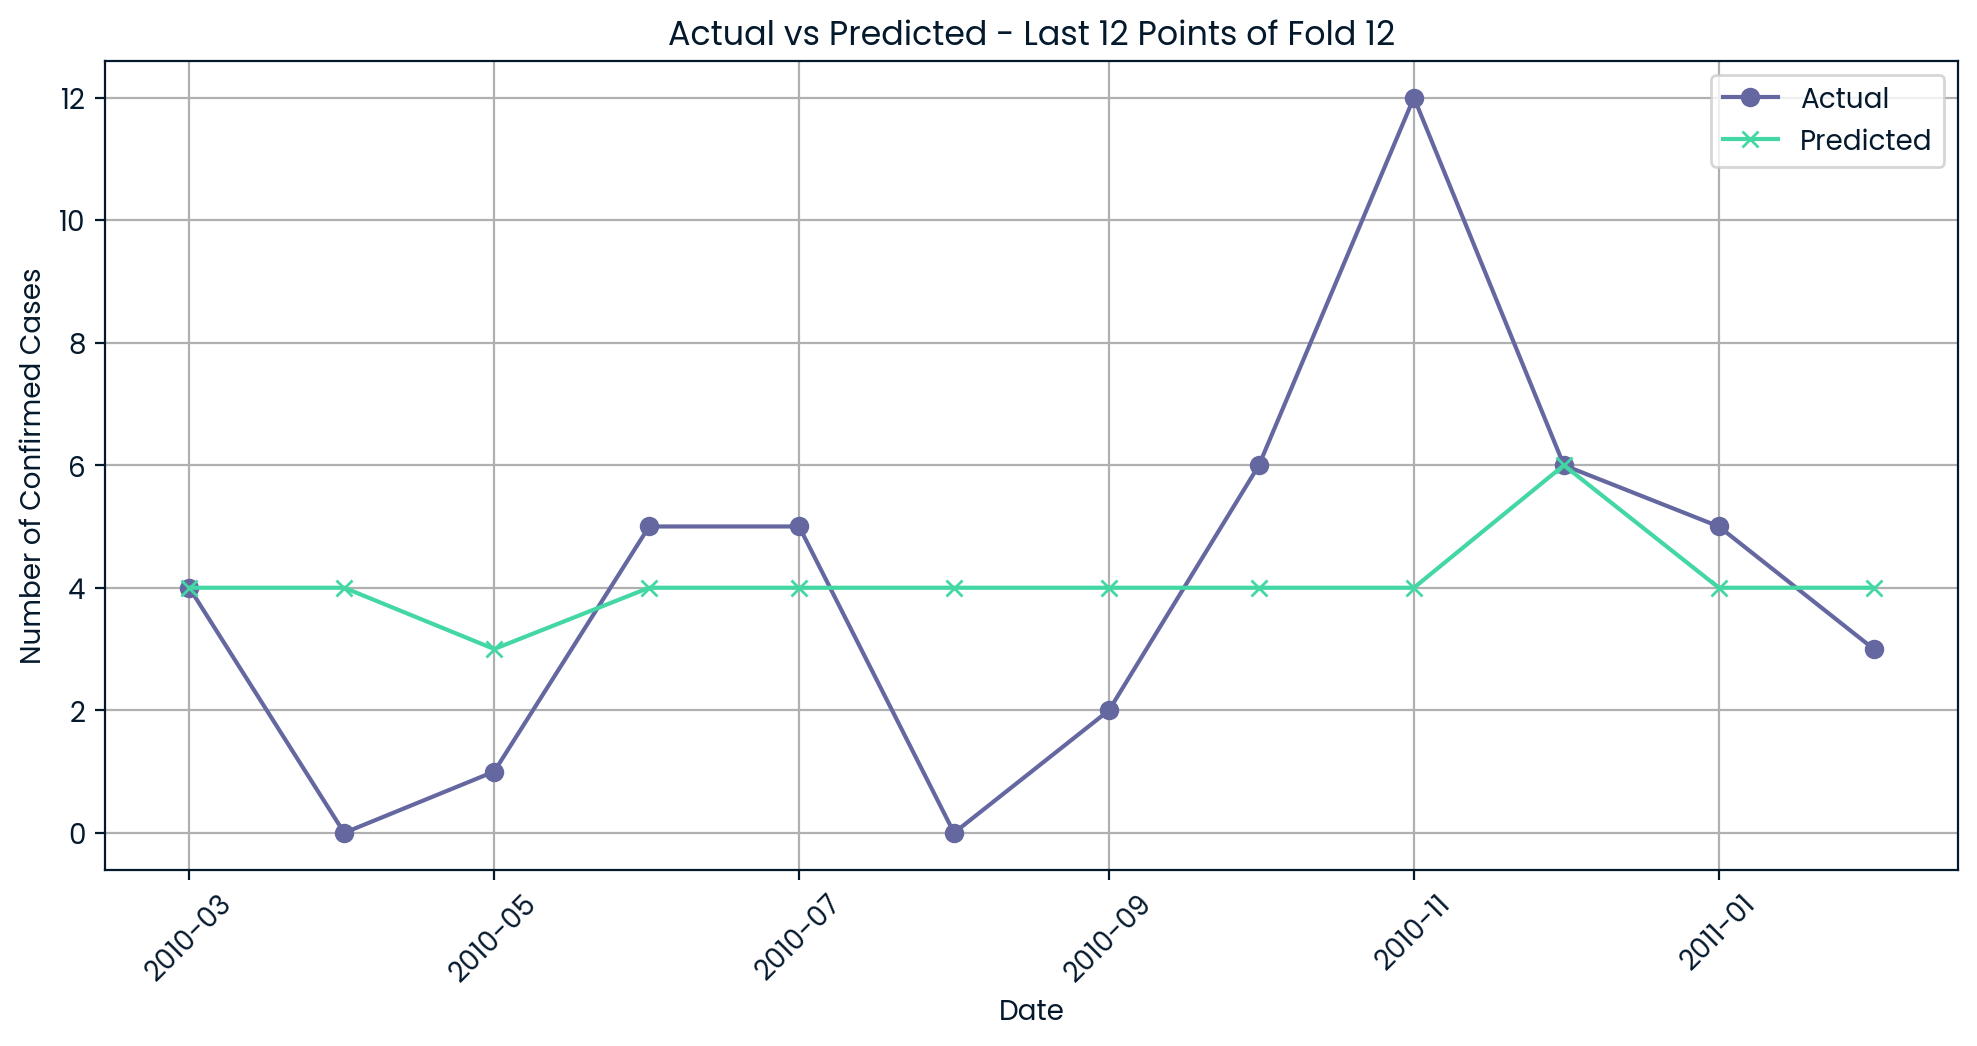

In [15]:
# ONE HYPEROPT PER TIME SERIES FOLD

from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from hyperopt import fmin, tpe, hp, Trials, space_eval
from sklearn.model_selection import KFold


df_lagged = create_lag_features(df.copy(), columns_to_lag=columns_to_lag, max_lag=10)
df_lagged = add_recent_zero_count(df_lagged, target_column='Number of Confirmed Cases', months=10)
feature_cols = [col for col in df_lagged.columns if 'lag_1' in col or 'lag_6' in col or 'lag_10' in col] + ['recent_zero_count']
target_col = 'Number of Confirmed Cases'
X = df_lagged[feature_cols].values
y = df_lagged[target_col].values

# TimeSeriesSplit Setup
n_splits_outer = 12
test_size = 12
tscv_outer = TimeSeriesSplit(n_splits=n_splits_outer, test_size=test_size)

# Hyperparameter search space for Hyperopt
param_space_hyperopt = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'max_depth': hp.quniform('max_depth', 2, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-6), np.log(10)),
}

all_mae_scores = []
all_best_hyperparams = []
final_predictions = pd.DataFrame({'DATE': [],
                                    'Actual': [],
                                    'Predicted': [],
                                    'Fold': []})

# Loop through the TimeSeriesSplit folds
for fold_idx, (train_index, test_index) in enumerate(tscv_outer.split(X)):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Objective function for Hyperopt (using TimeSeriesSplit for internal CV on the fold's training data)
    def objective_fold(params):
        model = XGBRegressor(
            n_estimators=int(params['n_estimators']),
            learning_rate=params['learning_rate'],
            max_depth=int(params['max_depth']),
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_lambda=params['reg_lambda'],
            random_state=42,
        )
        tscv_inner = TimeSeriesSplit(n_splits=3) # Using a few inner splits for validation
        mae_scores_inner = []
        for train_inner_index, val_inner_index in tscv_inner.split(X_train_fold):
            X_train_inner, X_val_inner = X_train_fold[train_inner_index], X_train_fold[val_inner_index]
            y_train_inner, y_val_inner = y_train_fold[train_inner_index], y_train_fold[val_inner_index]
            model.fit(X_train_inner, y_train_inner)
            y_pred_inner = model.predict(X_val_inner)
            mae_inner = mean_absolute_error(y_val_inner, np.round(y_pred_inner))
            mae_scores_inner.append(mae_inner)
        return np.mean(mae_scores_inner)

    # Run Hyperopt for the current fold
    trials_fold = Trials()
    best_fold = fmin(fn=objective_fold,
                     space=param_space_hyperopt,
                     algo=tpe.suggest,
                     max_evals=25,  # Adjust the number of evaluations per fold
                     trials=trials_fold,
                     rstate=np.random.default_rng(42 + fold_idx)) # Add fold_idx for different random states

    best_hyperparams_fold = space_eval(param_space_hyperopt, best_fold)
    all_best_hyperparams.append(best_hyperparams_fold)
    print(f"\nBest Hyperparameters for Fold {fold_idx + 1}:")
    print(best_hyperparams_fold)

    # Train the best model for this fold on the fold's training data
    best_model_fold = XGBRegressor(
        n_estimators=int(best_hyperparams_fold['n_estimators']),
        learning_rate=best_hyperparams_fold['learning_rate'],
        max_depth=int(best_hyperparams_fold['max_depth']),
        subsample=best_hyperparams_fold['subsample'],
        colsample_bytree=best_hyperparams_fold['colsample_bytree'],
        reg_lambda=best_hyperparams_fold['reg_lambda'],
        random_state=42,
    )
    best_model_fold.fit(X_train_fold, y_train_fold)

    # Predict on the test set of the current fold
    y_pred_fold = best_model_fold.predict(X_test_fold)
    y_pred_rounded_fold = np.round(y_pred_fold)

    # Evaluate the model
    mae_fold = mean_absolute_error(y_test_fold, y_pred_rounded_fold)
    all_mae_scores.append(mae_fold)
    print(f"Fold {fold_idx + 1} MAE: {mae_fold:.4f}")

    # Store the predictions of the current fold
    fold_predictions = pd.DataFrame({
        'DATE': df.iloc[test_index]['DATE'].values,
        'Actual': y_test_fold,
        'Predicted': y_pred_rounded_fold,
        'Fold': fold_idx + 1
    })
    final_predictions = pd.concat([final_predictions, fold_predictions], ignore_index=True)

# Find the index of the best fold (lowest MAE)
best_fold_index = np.argmin(all_mae_scores)
best_mae = all_mae_scores[best_fold_index]
best_hyperparameters_best_fold = all_best_hyperparams[best_fold_index]

print(f"\n--------------------------------------------------")
print(f"The index of the best fold (lowest MAE) is: {best_fold_index}")
print(f"The best MAE achieved is: {best_mae:.4f}")
print("\nHyperparameters of the best fold:")
print(f"  n_estimators: {int(best_hyperparameters_best_fold['n_estimators'])}")
print(f"  learning_rate: {best_hyperparameters_best_fold['learning_rate']:.4f}")
print(f"  max_depth: {int(best_hyperparameters_best_fold['max_depth'])}")
print(f"  subsample: {best_hyperparameters_best_fold['subsample']:.4f}")
print(f"  colsample_bytree: {best_hyperparameters_best_fold['colsample_bytree']:.4f}")
print(f"  reg_lambda: {best_hyperparameters_best_fold['reg_lambda']:.4f}")
print(f"--------------------------------------------------")

# Construct the best_model with hyperparameters from the best fold
best_model = XGBRegressor(
    n_estimators=int(best_hyperparameters_best_fold['n_estimators']),
    learning_rate=best_hyperparameters_best_fold['learning_rate'],
    max_depth=int(best_hyperparameters_best_fold['max_depth']),
    subsample=best_hyperparameters_best_fold['subsample'],
    colsample_bytree=best_hyperparameters_best_fold['colsample_bytree'],
    reg_lambda=best_hyperparameters_best_fold['reg_lambda'],
    random_state=42  # for reproducibility
)

print("\nBest XGBoost model constructed with hyperparameters from the best fold:")
print(f"Model Parameters (before training on full data): {best_model.get_params()}")

# Train the best model on the entire training dataset
best_model.fit(X, y)

print("\nBest XGBoost model trained on the entire training dataset.")
print(f"Model Parameters (after training on full data): {best_model.get_params()}")

# Get the predictions from the last fold
last_fold_predictions = final_predictions[final_predictions['Fold'] == n_splits_outer]

# Print the actual vs predicted for the last 12 periods
print("\nFinal Predictions (Last 12 periods):")
print(last_fold_predictions.tail(12)[['DATE', 'Actual', 'Predicted']].to_string(index=False))

# Plotting the last 12 points from the last fold
plt.clf()
plt.figure(figsize=(10, 5))
plt.plot(last_fold_predictions.tail(12)['DATE'], last_fold_predictions.tail(12)['Actual'], label='Actual', marker='o')
plt.plot(last_fold_predictions.tail(12)['DATE'], last_fold_predictions.tail(12)['Predicted'], label='Predicted', marker='x')
plt.title(f"Actual vs Predicted - Last 12 Points of Fold {n_splits_outer}")
plt.xlabel("Date")
plt.ylabel("Number of Confirmed Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


The evaluation of the last 12 months of typhoid fever cases revealed a MAE of 1.5 for the model optimized using Hyperopt. This result is slightly higher than the MAE of 1.417 achieved by the PBT-optimized model. This marginal difference in MAE suggests that, for this specific time series forecasting task and the chosen configurations, the PBT approach demonstrated a slightly better ability to accurately predict the number of confirmed typhoid fever cases in the final 12 data points compared to the model tuned with Hyperopt.


The slightly superior performance of PBT could indicate its strength in adapting hyperparameters dynamically during the training process across different time windows (folds). The evolutionary nature of PBT might have allowed it to find hyperparameter configurations that were better suited to the shifting temporal patterns within the data compared to Hyperopt's more static evaluation of hyperparameter sets per fold.


While Hyperopt's Bayesian optimization (TPE) is efficient in exploring the hyperparameter space, it might have converged to a slightly suboptimal configuration for the later time periods compared to PBT's continuous adaptation. The balance between exploration and exploitation could have played a role in PBT's finer-tuned performance.


It is important to note that the performance of both methods is sensitive to their own configurations (e.g., population size and perturbation parameters for PBT, number of evaluations and search space for Hyperopt). The observed difference might be influenced by the specific parameter settings used for each method. Further tuning of either method's parameters could potentially alter the outcome.


While PBT showed a slightly lower MAE, it's crucial to consider the practical significance of this difference. An absolute MAE difference of 0.08 might or might not be substantial depending on the scale of the predicted values and the acceptable error range for the forecasting task.



These results suggest that for predicting the final 12 months of this specific typhoid fever dataset, PBT's adaptive hyperparameter tuning demonstrated a marginal advantage over Hyperopt's Bayesian optimization approach as implemented in this study. However, further investigation into the sensitivity of both methods to their configurations and a deeper analysis of the dataset's temporal dynamics are warranted for more definitive conclusions.

Please note that this project is currently in its early stages of development. For this reason, the findings and interpretations presented here are preliminary and subject to further refinement. Should you have any questions or require further clarification, please do not hesitate to send them my way at jprmaulion[at]gmail[dot]com.